In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Path to dataset files: /kaggle/input/garbage-classification-v2
Contents of base_path (/kaggle/input):
['garbage-classification-v2']
Contents of path (/kaggle/input/garbage-classification-v2):
['standardized_384', 'original', 'standardized_256']


Checking for image folders in: /kaggle/input/garbage-classification-v2/original
Found categories: ['metal', 'glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic']

Found 12259 image files in total. Displaying samples:


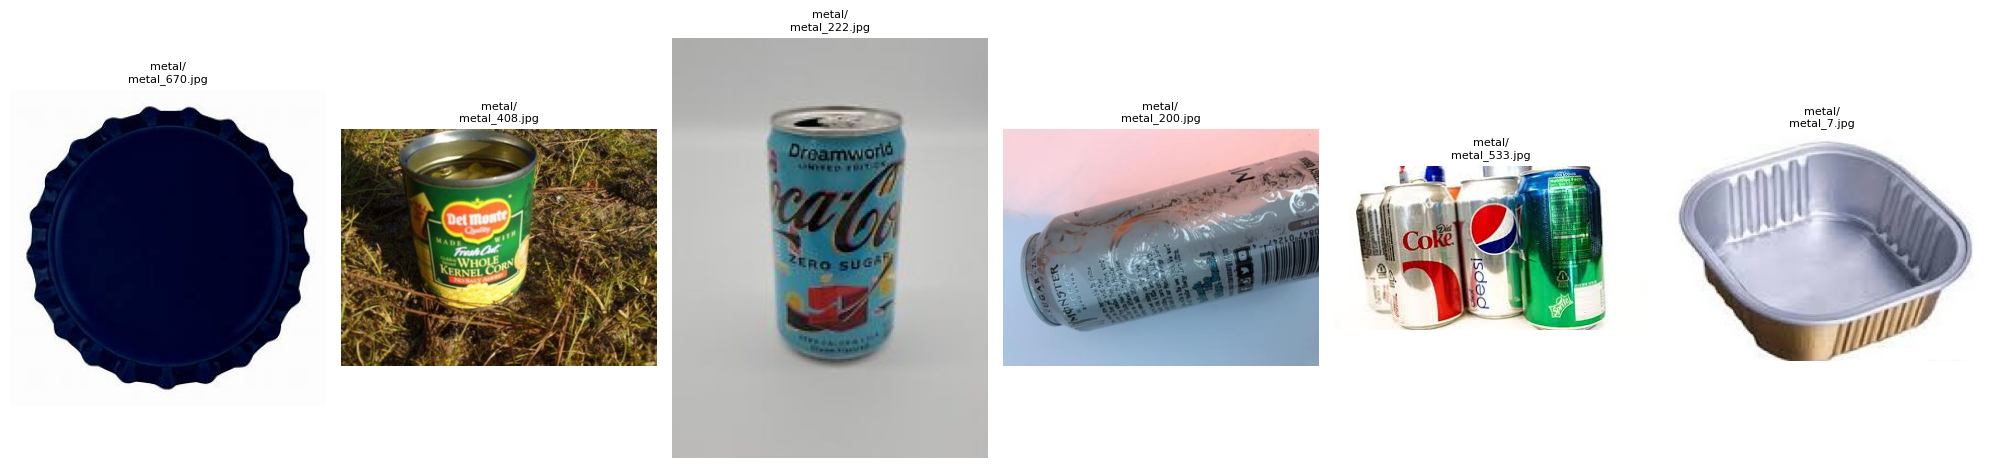

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the root directory containing the images
image_root_dir = os.path.join(path, 'original')

print(f"Checking for image folders in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found.")
else:
    # Get the list of subdirectories (garbage categories)
    categories = [d for d in os.listdir(image_root_dir) if os.path.isdir(os.path.join(image_root_dir, d))]
    print(f"Found categories: {categories}")

    all_image_paths = []
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')

    # Scan through each category folder to find images
    for category in categories:
        category_path = os.path.join(image_root_dir, category)
        for root, dirs, files in os.walk(category_path):
            for file in files:
                if file.lower().endswith(image_extensions):
                    all_image_paths.append(os.path.join(root, file))

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying samples:")

        # Select samples from different folders to display
        samples_to_display = all_image_paths[:min(len(all_image_paths), 6)]

        fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
        if len(samples_to_display) == 1:
            axes = [axes]

        for i, img_path in enumerate(samples_to_display):
            try:
                img = Image.open(img_path)
                axes[i].imshow(img)
                # Show parent directory name (category) and filename
                category_name = os.path.basename(os.path.dirname(img_path))
                axes[i].set_title(f"{category_name}/\n{os.path.basename(img_path)}", fontsize=8)
                axes[i].axis('off')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo images found in the category folders.")

In [ ]:
import random

# Set seed for reproducibility
random.seed(42)

# Dictionary to store the split results
dataset_split = {
    'train': [],
    'test': []
}

train_ratio = 0.8

# Group images by category to ensure stratified split
category_images = {}
for img_path in all_image_paths:
    category = os.path.basename(os.path.dirname(img_path))
    if category not in category_images:
        category_images[category] = []
    category_images[category].append(img_path)

# Perform the split for each category
for category, images in category_images.items():
    random.shuffle(images)
    split_idx = int(len(images) * train_ratio)

    dataset_split['train'].extend(images[:split_idx])
    dataset_split['test'].extend(images[split_idx:])

print(f"Split complete:")
print(f"- Total images: {len(all_image_paths)}")
print(f"- Training set: {len(dataset_split['train'])} ({len(dataset_split['train'])/len(all_image_paths):.1%})")
print(f"- Test set: {len(dataset_split['test'])} ({len(dataset_split['test'])/len(all_image_paths):.1%})")

Split complete:
- Total images: 12259
- Training set: 9802 (80.0%)
- Test set: 2457 (20.0%)


In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: Tesla T4


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Custom Dataset class
class GarbageDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        # Map category names to integers
        self.categories = sorted(list(set([os.path.basename(os.path.dirname(p)) for p in file_paths])))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.categories)}

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[os.path.basename(os.path.dirname(img_path))]
        if self.transform:
            image = self.transform(image)
        return image, label

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Data loaders
train_ds = GarbageDataset(dataset_split['train'], transform=transform)
test_ds = GarbageDataset(dataset_split['test'], transform=transform)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Build ResNet model
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_ds.categories))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Epoch 1/10 - Loss: 1.1632, Acc: 0.6175
Epoch 2/10 - Loss: 0.7116, Acc: 0.7739
Epoch 3/10 - Loss: 0.5618, Acc: 0.8164
Epoch 4/10 - Loss: 0.4833, Acc: 0.8423
Epoch 5/10 - Loss: 0.3811, Acc: 0.8750
Epoch 6/10 - Loss: 0.3368, Acc: 0.8877
Epoch 7/10 - Loss: 0.2716, Acc: 0.9093
Epoch 8/10 - Loss: 0.2378, Acc: 0.9202
Epoch 9/10 - Loss: 0.1978, Acc: 0.9345
Epoch 10/10 - Loss: 0.1897, Acc: 0.9359


In [ ]:
# Evaluate and summarize
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_accuracy = 100 * correct / total
print("--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.2%}")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

--- Training Summary ---
Final Training Accuracy: 93.59%
Final Training Loss: 0.1897
Test Accuracy: 82.17%


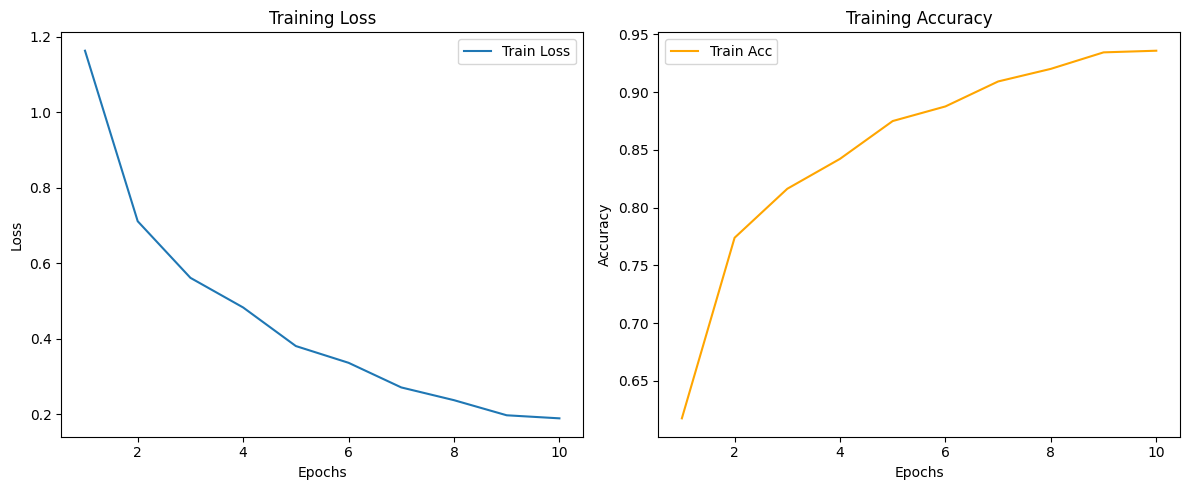

In [ ]:
# Visualize training results
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), history['train_loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), history['train_acc'], label='Train Acc', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()